# 01_eda_rrhh (versión corregida)

Notebook de análisis exploratorio robusto para RRHH, con carga segura, limpieza base, validaciones y salidas reproducibles.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

POSSIBLE_PATHS = [
    Path('../data/03_primary/rrhh_encoded.csv'),
    Path('data/03_primary/rrhh_encoded.csv'),
    Path('/home/user/rrhh_encoded.csv')
]
RUTA = next((p for p in POSSIBLE_PATHS if p.exists()), None)
if RUTA is None:
    raise FileNotFoundError('No se encontró rrhh_encoded.csv en rutas esperadas.')
print('Archivo usado:', RUTA)


Archivo usado: ..\data\03_primary\rrhh_encoded.csv


In [2]:

df = pd.read_csv(RUTA, encoding='cp1252')
df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]
print('Shape:', df.shape)
display(df.head())
display(df.info())


Shape: (286, 62)


,id_empleado,nombre,rut,departamento,cargo,fecha_ingreso,salario,tipo_contrato,jornada,antiguedad_anios,total_ausencias,dias_ausencia_total,dias_ausencia_promedio,ausencias_injustificadas,tipo_ausencia_mas_frecuente,dias_ausencia_just_no,dias_ausencia_just_sã­,total_capacitaciones,horas_capacitacion_total,horas_capacitacion_promedio,nota_promedio_capacitacion,capacitaciones_completadas,cumple_min_capacitaciones,nota_estado_abandonado,nota_estado_completado,nota_estado_en_curso,nota_estado_inscrito,total_evaluaciones,puntaje_desempeno_promedio,competencias_tecnicas_promedio,competencias_blandas_promedio,puntaje_desempeno_max,puntaje_desempeno_min,tasa_ausentismo_pct,tasa_completitud_cap,score_desempeno,segmento_desempeno,riesgo_ausentismo,salario_norm,dias_ausencia_total_norm,horas_capacitacion_total_norm,puntaje_desempeno_promedio_norm,competencias_tecnicas_promedio_std,competencias_blandas_promedio_std,tipo_contrato_enc,jornada_enc,departamento_finanzas,departamento_legal,departamento_logã?stica,departamento_logã­stica,departamento_marketing,departamento_operaciones,departamento_rrhh,departamento_ti,departamento_ventas,tipo_ausencia_mas_frecuente_desconocido,tipo_ausencia_mas_frecuente_falta_injustificada,tipo_ausencia_mas_frecuente_licencia_maternal,tipo_ausencia_mas_frecuente_licencia_mã?dica,tipo_ausencia_mas_frecuente_licencia_mã©dica,tipo_ausencia_mas_frecuente_permiso,tipo_ausencia_mas_frecuente_vacaciones
0,1,Lorena Rivera Tapia,10830786-7,Operaciones,Jefe,2015-01-01,1147033.0,Indefinido,Completa,11.4,1.0,17.0,17.00,1.0,Licencia Mã?Dica,17.0,0.0,1.0,40.0,40.0,5.70,1.0,1.0,0.0,5.7,0.0,0.0,1.0,4.20,1.7,5.80,4.2,4.2,6.8,100.0,3.77,Medio,Moderado,0.0995,0.0749,0.1370,0.6000,-0.8414,1.3004,1.0,0.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
1,2,Ignacio Nãºã±Ez Hernã¡Ndez,23306873-1,Logã­Stica,Analista,2015-01-12,4563559.0,Plazo Fijo,Completa,11.3,1.0,29.0,29.00,0.0,Permiso,0.0,29.0,2.0,64.0,32.0,2.65,1.0,1.0,3.2,2.1,0.0,0.0,1.0,6.30,3.9,1.30,6.3,6.3,11.6,50.0,4.58,Medio,Crítico,0.6300,0.1278,0.2192,0.9000,0.2454,-0.9899,2.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2,3,Josã© Dã­Az Muã±Oz,6281564-5,Rrhh,Analista,2015-01-24,876120.0,Indefinido,Completa,11.3,3.0,38.0,12.67,1.0,Licencia Maternal,20.0,18.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,3.0,3.43,5.2,4.67,4.8,1.3,15.2,0.0,4.21,Medio,Crítico,0.0574,0.1674,0.0000,0.4900,0.8876,0.7253,1.0,0.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
3,4,Felipe Castro Muã±Oz,5967608-9,Operaciones,Analista,2015-02-04,4201812.0,Prã¡Ctica,Completa,11.3,1.0,21.0,21.00,1.0,Licencia Maternal,21.0,0.0,1.0,16.0,16.0,6.50,0.0,0.0,0.0,0.0,6.5,0.0,0.0,NaN,NaN,NaN,NaN,NaN,8.4,0.0,0.00,Bajo,Moderado,0.5738,0.0925,0.0548,0.0000,-1.6811,-1.6516,3.0,0.0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,5,Carolina Zambrano Dã­Az,10140262-2,Rrhh,Coordinador,2015-02-16,1183831.0,Plazo Fijo,Completa,11.2,1.0,27.0,27.00,0.0,Licencia Mã©Dica,0.0,27.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,1.0,6.00,1.7,3.10,6.0,6.0,10.8,0.0,4.13,Medio,Crítico,0.1052,0.1189,0.0000,0.8571,-0.8414,-0.0738,2.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 62 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   id_empleado                                      286 non-null    int64  
 1   nombre                                           270 non-null    object 
 2   rut                                              272 non-null    object 
 3   departamento                                     286 non-null    object 
 4   cargo                                            286 non-null    object 
 5   fecha_ingreso                                    277 non-null    object 
 6   salario                                          286 non-null    float64
 7   tipo_contrato                                    286 non-null    object 
 8   jornada                                          286 non-null    object 
 9   antiguedad_anios                

None

In [3]:

# Limpieza base para EDA
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

resumen_nulos = df.isna().sum().sort_values(ascending=False)
display(resumen_nulos.head(20))
display(df.describe(include='all').T.head(30))


dias_ausencia_just_sã­            97
dias_ausencia_just_no             97
dias_ausencia_promedio            93
tipo_ausencia_mas_frecuente       93
horas_capacitacion_promedio       79
nota_promedio_capacitacion        79
nota_estado_abandonado            79
nota_estado_completado            79
nota_estado_en_curso              79
nota_estado_inscrito              79
competencias_tecnicas_promedio    51
puntaje_desempeno_promedio        51
puntaje_desempeno_max             51
competencias_blandas_promedio     51
puntaje_desempeno_min             51
nombre                            16
rut                               14
fecha_ingreso                      9
antiguedad_anios                   9
salario                            0
dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_empleado,286.0,NaN,NaN,NaN,148.979021,86.546973,1.0,74.25,147.5,221.75,300.0
nombre,270,269,Bã¡Rbara Bravo Jara,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rut,272,272,10830786-7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departamento,286,9,Ventas,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cargo,286,7,Analista,61,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_ingreso,277,277,2015-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario,286.0,NaN,NaN,NaN,2794481.402098,1331287.254589,506416.0,1766484.75,2760325.0,3768558.0,6946153.0
tipo_contrato,286,4,Indefinido,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jornada,286,3,Completa,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
antiguedad_anios,277.0,NaN,NaN,NaN,6.688087,2.735377,1.9,4.4,6.7,9.1,11.4


,mean,std,min,max
id_empleado,1.489790e+02,8.654697e+01,1.0,300.0
salario,2.794481e+06,1.331287e+06,506416.0,6946153.0
antiguedad_anios,6.688087e+00,2.735377e+00,1.9,11.4
total_ausencias,1.097902e+00,1.296769e+00,0.0,15.0
dias_ausencia_total,1.676573e+01,2.213541e+01,0.0,227.0
dias_ausencia_promedio,1.502010e+01,7.399942e+00,1.0,29.0
ausencias_injustificadas,2.062937e-01,4.695226e-01,0.0,3.0
dias_ausencia_just_no,4.105820e+00,8.222919e+00,0.0,44.0
dias_ausencia_just_sã­,2.040212e+01,2.308719e+01,0.0,225.0
total_capacitaciones,1.223776e+00,1.068986e+00,0.0,7.0


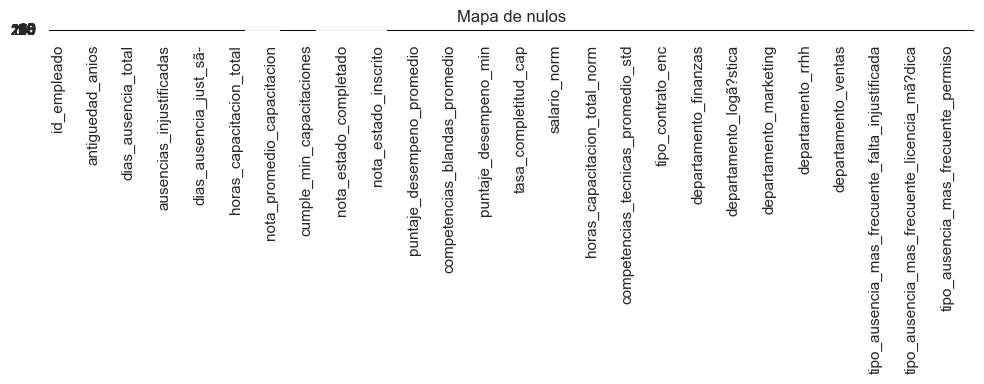

In [4]:

# Gráficos mínimos de diagnóstico
if num_cols:
    top = df[num_cols].describe().T[['mean', 'std', 'min', 'max']].head(10)
    display(top)
    plt.figure(figsize=(10, 4))
    sns.heatmap(df[num_cols].isna(), cbar=False)
    plt.title('Mapa de nulos')
    plt.tight_layout()
    plt.show()
